## 8. Putting it all together by building a multi-class classification model.

(Date - 5/Apr/2026)

In [42]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import plot_decision_boundary

### 8.1 Creating a toy multi-class dataset

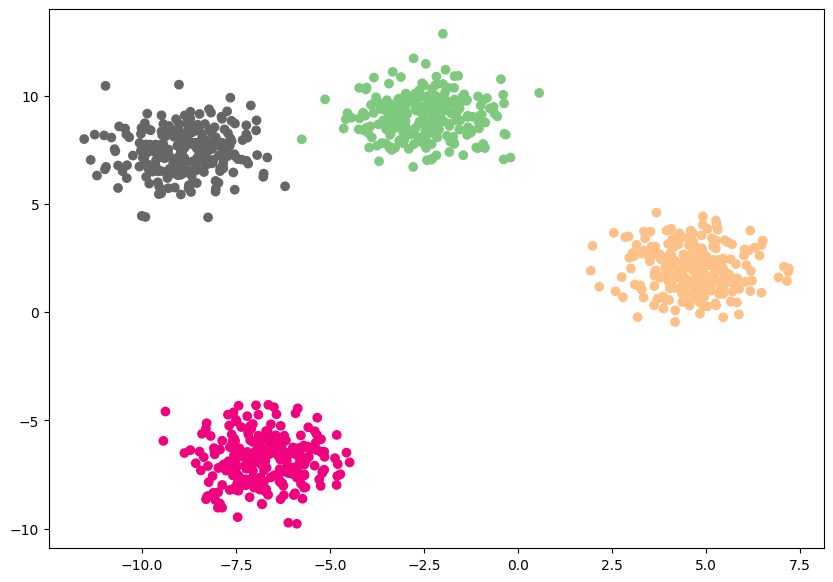

In [2]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, Y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            cluster_std=1,
                            centers=NUM_CLASSES,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
Y_blob = torch.from_numpy(Y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, Y_blob_train, Y_blob_test = train_test_split(X_blob,
                                                                        Y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)




plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=Y_blob, cmap=plt.cm.Accent);

### 8.2 Building a multi-class classification model

(Date - 6/Apr/2026)

In [3]:
# Create a device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        
        """ 
        Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features)  
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)


blob_model = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)
blob_model


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [5]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    accuracy = (correct / len(y_pred)) * 100 
    return accuracy

### 8.3 Creating a loss function and an optimizer

In [6]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=blob_model.parameters(),
                            lr=0.1)

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

(Date - 7/Apr/2026)

In [7]:
blob_model.eval()
with torch.inference_mode():
    y_logits = blob_model(X_blob_train).to(device)

y_logits[:5]

tensor([[ 1.0708, -0.3699,  0.0128, -1.0684],
        [ 0.5301,  0.4000, -1.2110, -0.2426],
        [-1.5864, -0.6690,  1.1221,  1.2316],
        [-1.1175, -0.5125,  0.7453,  0.8704],
        [ 0.3448,  0.3072, -1.0081, -0.1132]])

In [8]:
y_logits.argmax(dim=1)[:100]

tensor([0, 0, 3, 3, 0, 0, 1, 0, 3, 1, 0, 0, 3, 2, 3, 2, 0, 0, 3, 3, 2, 3, 3, 0,
        3, 2, 3, 0, 0, 0, 1, 0, 0, 3, 0, 3, 3, 0, 0, 1, 0, 0, 3, 3, 3, 0, 1, 0,
        0, 0, 1, 1, 3, 0, 0, 0, 1, 0, 2, 3, 3, 0, 0, 2, 0, 3, 3, 3, 2, 0, 0, 2,
        3, 0, 0, 0, 2, 0, 0, 0, 2, 3, 0, 3, 3, 3, 3, 3, 3, 2, 0, 0, 1, 0, 3, 0,
        3, 0, 2, 0])

In [9]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 1.0708, -0.3699,  0.0128, -1.0684],
        [ 0.5301,  0.4000, -1.2110, -0.2426],
        [-1.5864, -0.6690,  1.1221,  1.2316],
        [-1.1175, -0.5125,  0.7453,  0.8704],
        [ 0.3448,  0.3072, -1.0081, -0.1132]])
tensor([[0.5877, 0.1391, 0.2040, 0.0692],
        [0.3976, 0.3491, 0.0697, 0.1836],
        [0.0284, 0.0710, 0.4257, 0.4750],
        [0.0603, 0.1105, 0.3887, 0.4405],
        [0.3504, 0.3374, 0.0906, 0.2216]])


In [10]:
torch.sum(y_pred_probs[0]) 

tensor(1.)

In [11]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:100]

tensor([0, 0, 3, 3, 0, 0, 1, 0, 3, 1, 0, 0, 3, 2, 3, 2, 0, 0, 3, 3, 2, 3, 3, 0,
        3, 2, 3, 0, 0, 0, 1, 0, 0, 3, 0, 3, 3, 0, 0, 1, 0, 0, 3, 3, 3, 0, 1, 0,
        0, 0, 1, 1, 3, 0, 0, 0, 1, 0, 2, 3, 3, 0, 0, 2, 0, 3, 3, 3, 2, 0, 0, 2,
        3, 0, 0, 0, 2, 0, 0, 0, 2, 3, 0, 3, 3, 3, 3, 3, 3, 2, 0, 0, 1, 0, 3, 0,
        3, 0, 2, 0])

In [12]:
Y_blob_test[:100]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2])

In [13]:
Y_blob_train[:10]

tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0])

### 8.5 Creating a training and testing loop

(Date - 8/Apr/2026)

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_blob_train, Y_blob_train = X_blob_train.to(device), Y_blob_train.to(device)
X_blob_test, Y_blob_test = X_blob_test.to(device), Y_blob_test.to(device)

for epoch in range(epochs):
    blob_model.train()

    Y_logits = blob_model(X_blob_train)
    Y_pred = torch.softmax(Y_logits, dim = 1).argmax(dim=1)

    train_loss = loss_fn(Y_logits, Y_blob_train)
    acc = accuracy_fn(y_true=Y_blob_train,
                      y_pred = Y_pred)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    blob_model.eval()
    with torch.inference_mode():
        test_logits = blob_model(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, Y_blob_test)
        test_acc = accuracy_fn(y_true=Y_blob_test,
                               y_pred=test_preds)
        
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {train_loss:.4f} | Acc: {acc:.2f} | Test Loss: {test_loss:.4f} | Test accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 10 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 20 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 30 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 40 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 50 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 60 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 70 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 80 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00
Epoch: 90 | Loss: 0.0015 | Acc: 100.00 | Test Loss: 0.0006 | Test accuracy: 100.00


### 8.6 Making and evaluating predictions 

(Date - 9/Apr/2026)

In [39]:
blob_model.eval()
with torch.inference_mode():
    Y_logits = blob_model(X_blob_test)

Y_logits[:10]

tensor([[ 14.4918,  24.8903, -20.0495, -15.6257],
        [  2.7346, -23.5012,   3.7054,  15.2485],
        [-24.1712, -33.4063,  31.8001,  19.5897],
        [  9.0771,  19.6281, -13.5441, -12.6024],
        [ 18.8771,   9.4996, -20.1988,  -5.1503],
        [  2.3781, -27.4769,   5.0791,  17.8342],
        [-23.3999, -28.9949,  29.9194,  16.7509],
        [ 15.3996,   3.1217, -15.2397,  -1.2368],
        [-26.5320, -41.0641,  36.0335,  24.4351],
        [ 16.4608,   5.3918, -16.8374,  -2.6440]])

In [40]:
y_pred_probs = torch.softmax(Y_logits, dim=1)
y_pred_probs[:10]

tensor([[3.0478e-05, 9.9997e-01, 3.0401e-20, 2.5358e-18],
        [3.6752e-06, 1.4833e-17, 9.7033e-06, 9.9999e-01],
        [4.9201e-25, 4.8000e-29, 9.9999e-01, 4.9787e-06],
        [2.6167e-05, 9.9997e-01, 3.9217e-15, 1.0056e-14],
        [9.9992e-01, 8.4606e-05, 1.0704e-17, 3.6730e-11],
        [1.9387e-07, 2.0971e-20, 2.8875e-06, 1.0000e+00],
        [6.9782e-24, 2.5934e-26, 1.0000e+00, 1.9099e-06],
        [1.0000e+00, 4.6533e-06, 4.9376e-14, 5.9556e-08],
        [6.7319e-28, 3.2880e-34, 9.9999e-01, 9.1800e-06],
        [9.9998e-01, 1.5588e-05, 3.4574e-15, 5.0452e-09]])

In [41]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

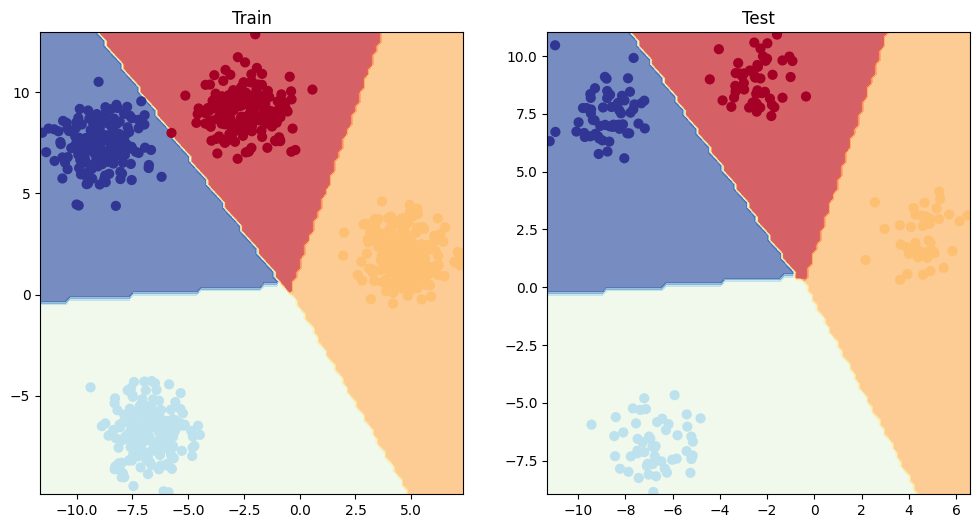

In [44]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(blob_model, X_blob_train, Y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(blob_model, X_blob_test, Y_blob_test)

A few more classification metrics to evaluate our model are in the next file (26.ipynb)